In [1]:
import pandas as pd
import numpy as np
from utils.mpip_parse import MPIPParser
from utils.parse_coscheduling_runs import CoSchedulingRunsParser
import matplotlib.pyplot as plt
from utils.parse_rate_limits import RateLimitParser

In [13]:
parser = CoSchedulingRunsParser()
data_isolated = parser.parse_isolated("../run_data/experiments_coscheduling_isolated/20260527_083005/data", progress=True)
data_coscheduled = parser.parse_coscheduled("../run_data/experiments_coscheduling_app_coscheduled/20260527_082956/data", progress=True)

Phase 1: Collecting files: 64it [00:00, 10195.04it/s]
Phase 2: Parsing files: 100%|██████████| 64/64 [00:19<00:00,  3.34it/s]
Phase 1: Collecting files: 304it [00:00, 10457.72it/s]
Phase 2: Parsing files: 100%|██████████| 304/304 [03:28<00:00,  1.46it/s]


,App,Num Nodes,App Time Average Mean,App Time Average Median,App Time Average Std,MPI Time Average Mean,MPI Time Average Median,MPI Time Average Std,Total Messages Sent Mean,Total Messages Sent Median,Total Messages Sent Std,Total Bytes Sent Mean,Total Bytes Sent Median,Total Bytes Sent Std
0,amg,8,342.500000,343.000000,1.000000,12.778086,13.185714,0.995017,106441449.0,106441449.0,0.0,1.008232e+12,1.008232e+12,0.0
2,beatnik,8,397.734375,396.977679,4.860808,99.906362,98.491295,3.282818,19996182.0,19996182.0,0.0,1.092655e+13,1.092655e+13,0.0
4,fiesta,8,359.091518,357.470982,3.688871,65.675446,64.003013,5.682057,645120.0,645120.0,0.0,1.640000e+12,1.640000e+12,0.0
5,kripke,8,354.500000,354.500000,0.577350,17.006585,16.945201,0.547324,302720.0,302720.0,0.0,3.880387e+11,3.880387e+11,0.0
6,laghos,8,331.237723,332.007812,15.994063,54.944978,55.503237,15.080986,801311390.0,801311390.0,0.0,6.337223e+11,6.337223e+11,0.0
8,lammps,8,354.750000,356.000000,3.304038,17.381222,17.574632,2.804269,457408.0,457408.0,0.0,6.704208e+11,6.704208e+11,0.0
10,minife,8,388.250000,388.000000,0.500000,13.601356,13.545246,0.315311,6788000.0,6788000.0,0.0,3.822487e+11,3.822487e+11,0.0
12,minivite,8,371.250000,370.500000,4.193249,51.597266,51.530469,2.688986,24089720.0,24089720.0,0.0,1.134700e+12,1.134700e+12,0.0
13,quicksilver,8,295.000000,295.000000,0.816497,133.995497,133.839967,0.696344,762710.0,762710.0,0.0,1.601104e+08,1.601104e+08,0.0
15,tricount,8,378.000000,379.000000,5.291503,204.072545,205.280134,5.325894,7120960.0,7120960.0,0.0,1.020000e+13,1.020000e+13,0.0


In [14]:
# Aggregate data_isolated by App and Num Nodes
# Group by App and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_isolated_agg = data_isolated.groupby(['App', 'Num Nodes']).agg({
    'App Time Average': ['mean', 'median', 'std'],
    'MPI Time Average': ['mean', 'median', 'std'],
    'Total Messages Sent': ['mean', 'median', 'std'],
    'Total Bytes Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_isolated_agg.columns = ['App', 'Num Nodes', 
                             'App Time Average Mean', 'App Time Average Median', 'App Time Average Std',
                             'MPI Time Average Mean', 'MPI Time Average Median', 'MPI Time Average Std',
                             'Total Messages Sent Mean', 'Total Messages Sent Median', 'Total Messages Sent Std',
                             'Total Bytes Sent Mean', 'Total Bytes Sent Median', 'Total Bytes Sent Std']

data_isolated_agg[data_isolated_agg["Num Nodes"] == 8]

# Aggregate data_coscheduled by App A, App B, and Num Nodes
# Group by App A, App B, and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_coscheduled_agg = data_coscheduled.groupby(['App A', 'App B', 'Num Nodes']).agg({
    'App A Time Average': ['mean', 'median', 'std'],
    'App B Time Average': ['mean', 'median', 'std'],
    'App A MPI Time Average': ['mean', 'median', 'std'],
    'App B MPI Time Average': ['mean', 'median', 'std'],
    'App A Total Messages Sent': ['mean', 'median', 'std'],
    'App B Total Messages Sent': ['mean', 'median', 'std'],
    'App A Total Bytes Sent': ['mean', 'median', 'std'],
    'App B Total Bytes Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_coscheduled_agg.columns = ['App A', 'App B', 'Num Nodes',
                                'App A Time Average Mean', 'App A Time Average Median', 'App A Time Average Std',
                                'App B Time Average Mean', 'App B Time Average Median', 'App B Time Average Std',
                                'App A MPI Time Average Mean', 'App A MPI Time Average Median', 'App A MPI Time Average Std',
                                'App B MPI Time Average Mean', 'App B MPI Time Average Median', 'App B MPI Time Average Std',
                                'App A Total Messages Sent Mean', 'App A Total Messages Sent Median', 'App A Total Messages Sent Std',
                                'App B Total Messages Sent Mean', 'App B Total Messages Sent Median', 'App B Total Messages Sent Std',
                                'App A Total Bytes Sent Mean', 'App A Total Bytes Sent Median', 'App A Total Bytes Sent Std',
                                'App B Total Bytes Sent Mean', 'App B Total Bytes Sent Median', 'App B Total Bytes Sent Std']

In [15]:
rate_limit_parser = RateLimitParser("/home/akhil/hpcResearch/repos/coScheduling/rate_limit_data/20260625_114931/data")
rate_limit_parser.parse()
rate_limits = rate_limit_parser.get_rate_limits()
bandwidths = rate_limit_parser.get_bandwidths()

In [16]:
rate_limits

,Rank A,Rank B,Rate Limit (messages/sec),Run Index
0,0,1,7651560.0,0
1,0,2,5711840.0,0
2,0,3,5673710.0,0
3,0,4,6669250.0,0
4,0,5,6617080.0,0
...,...,...,...,...
555,7,2,3923370.0,9
556,7,3,3922580.0,9
557,7,4,5017810.0,9
558,7,5,3981720.0,9


In [17]:
bandwidths

,Rank A,Rank B,Bandwidth (MB/s),Run Index
0,0,1,24811.26,0
1,0,2,22670.20,0
2,0,3,22474.78,0
3,0,4,14070.80,0
4,0,5,14171.33,0
...,...,...,...,...
555,7,2,10297.39,9
556,7,3,9966.91,9
557,7,4,22344.90,9
558,7,5,22406.57,9


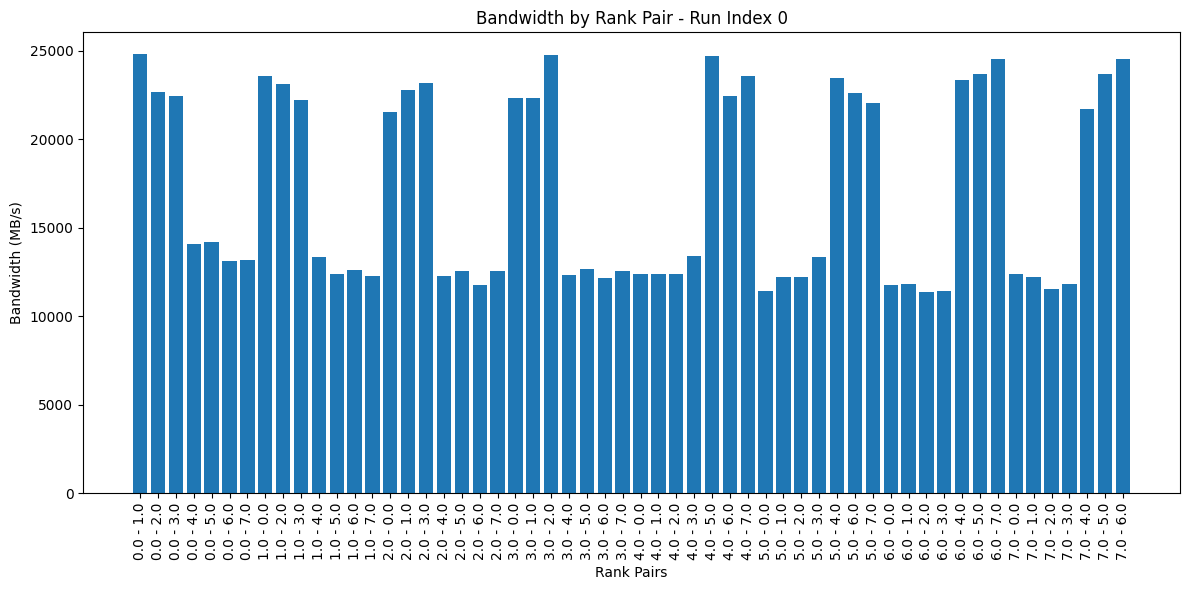

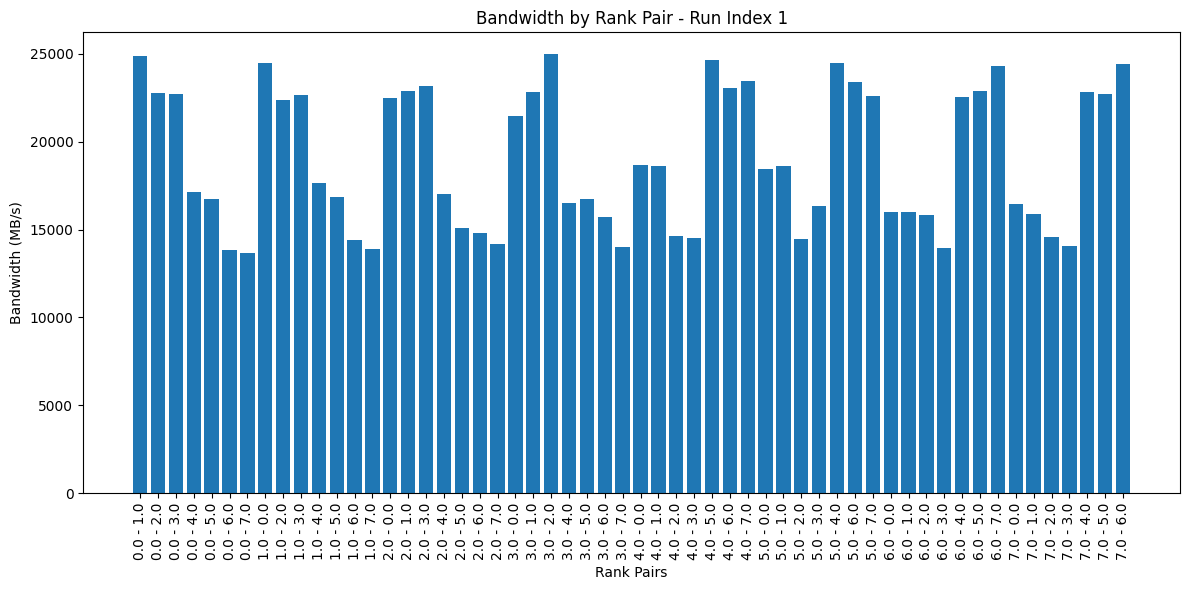

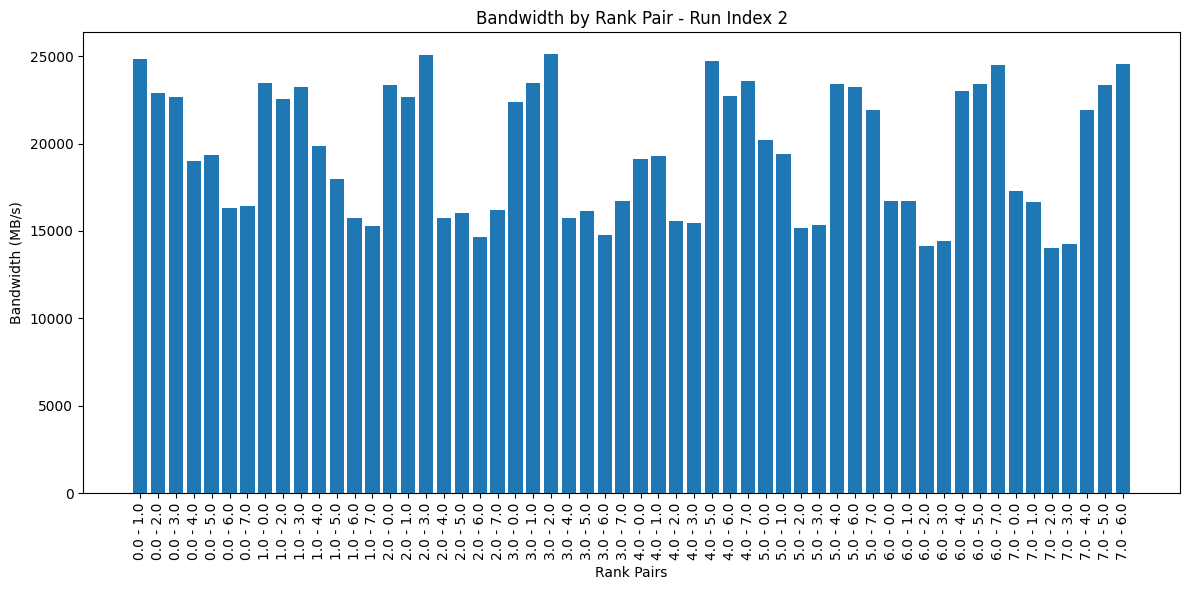

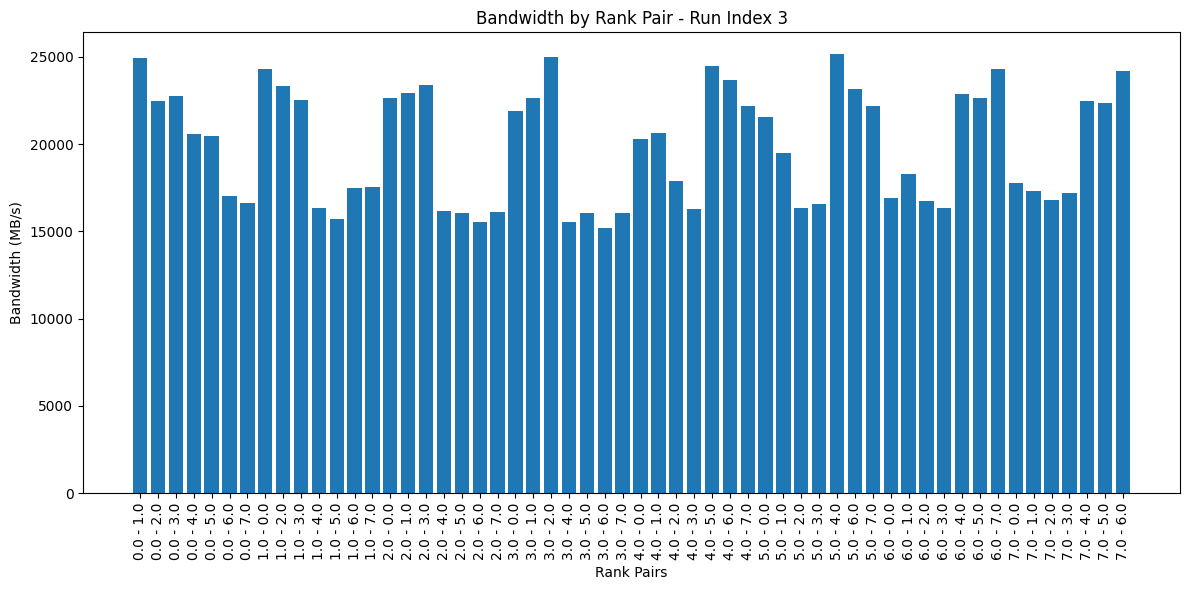

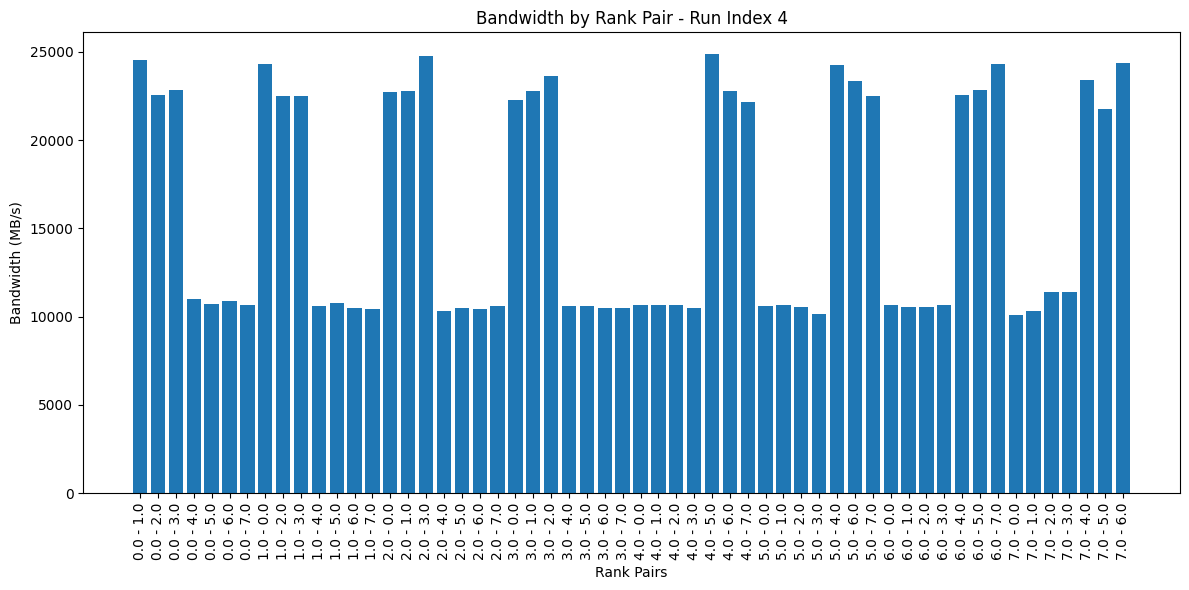

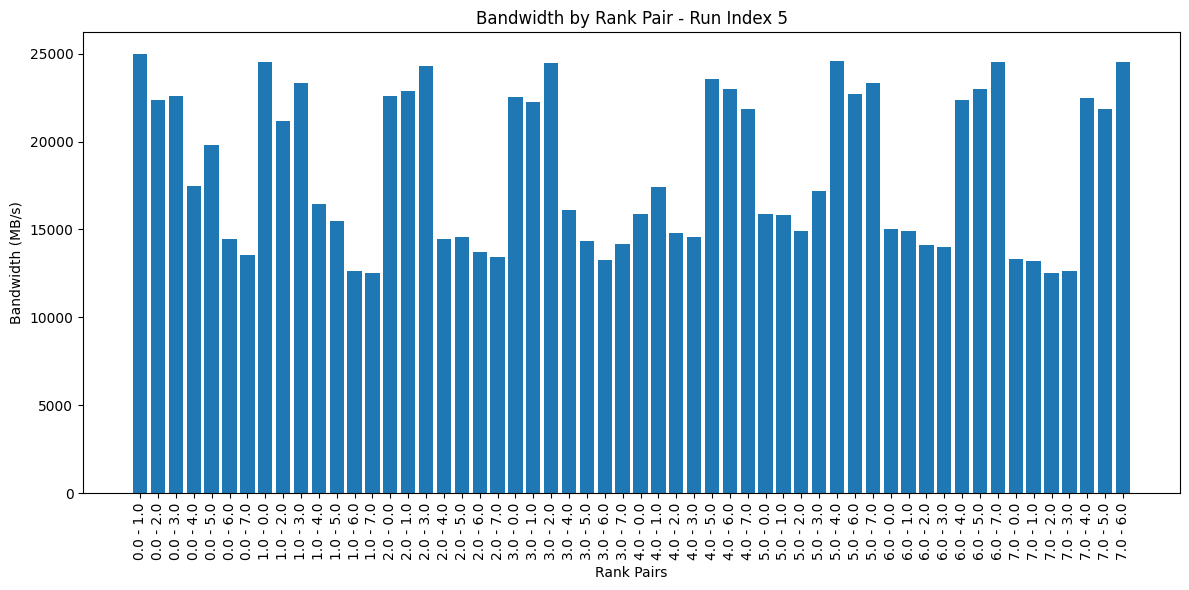

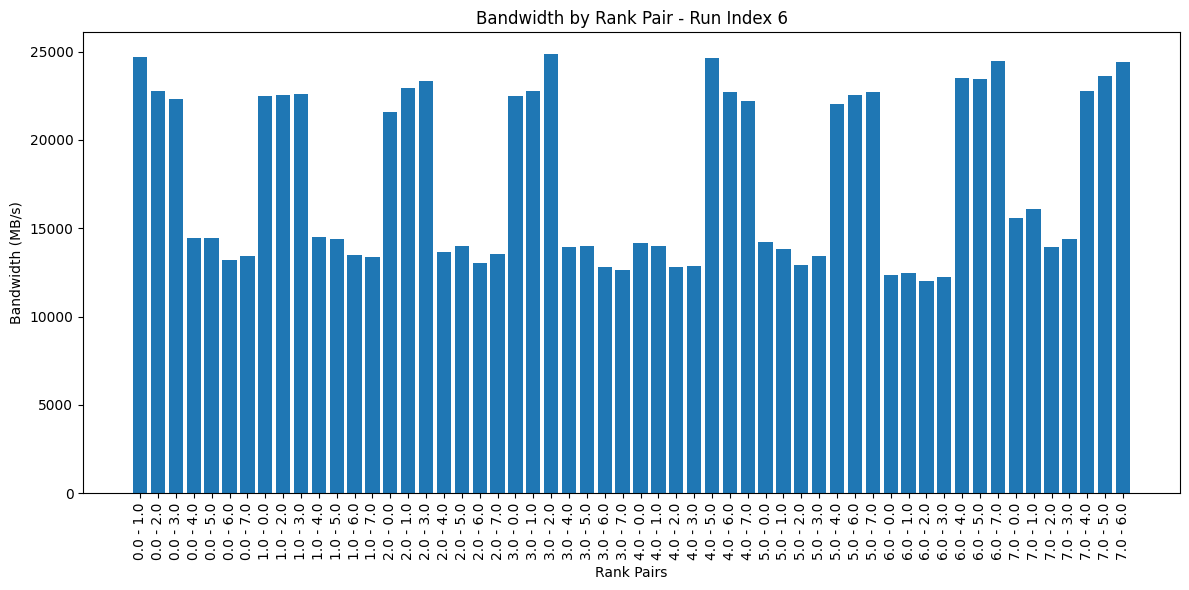

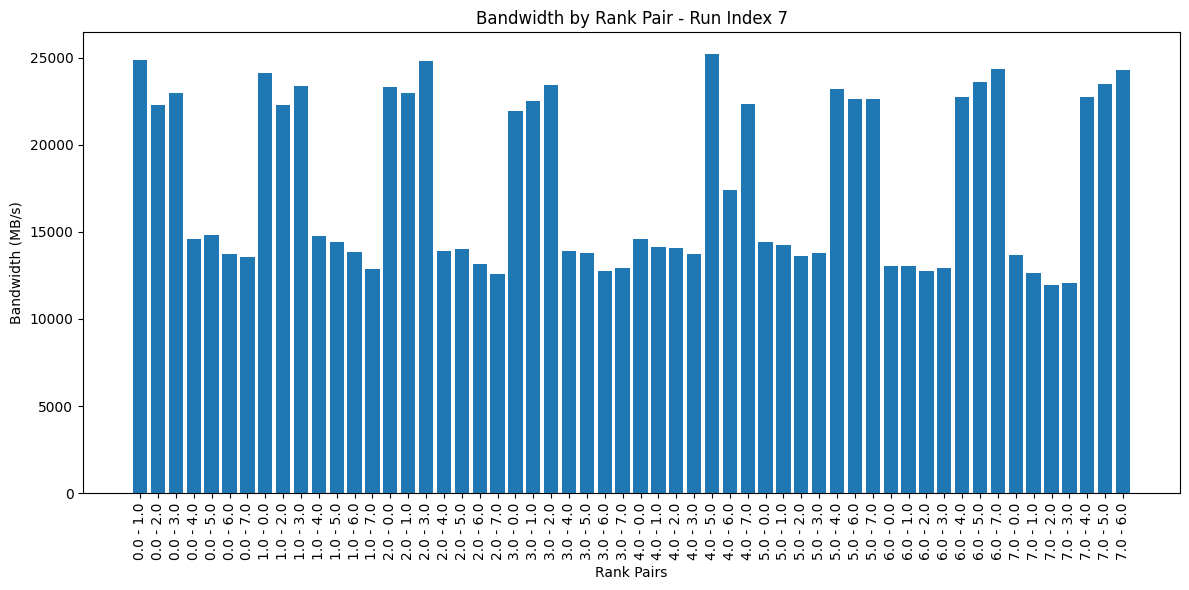

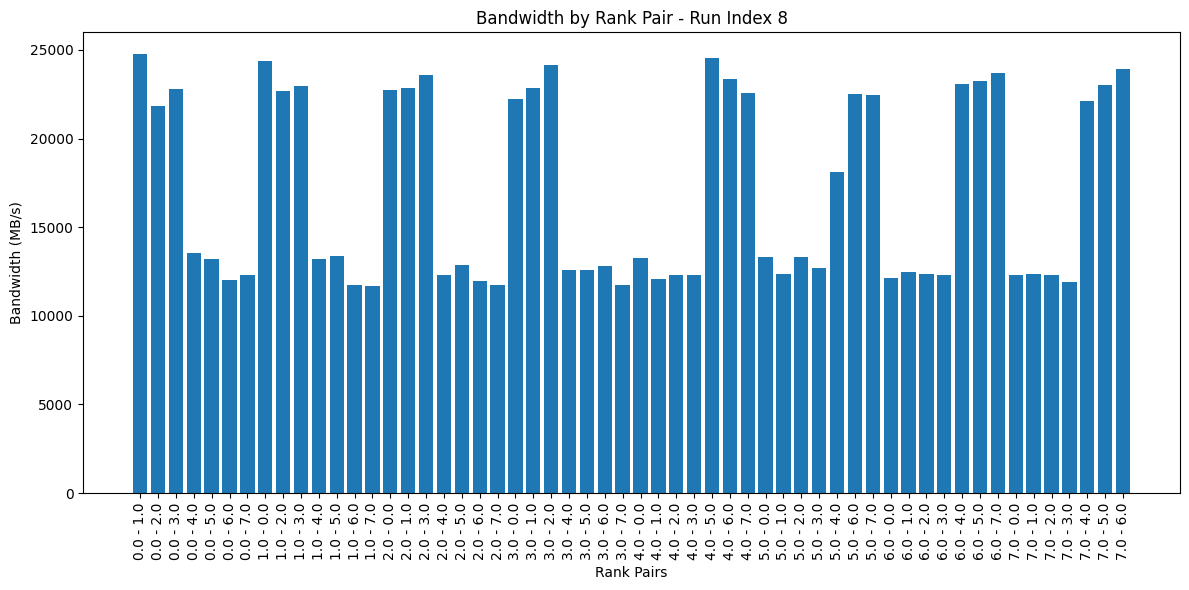

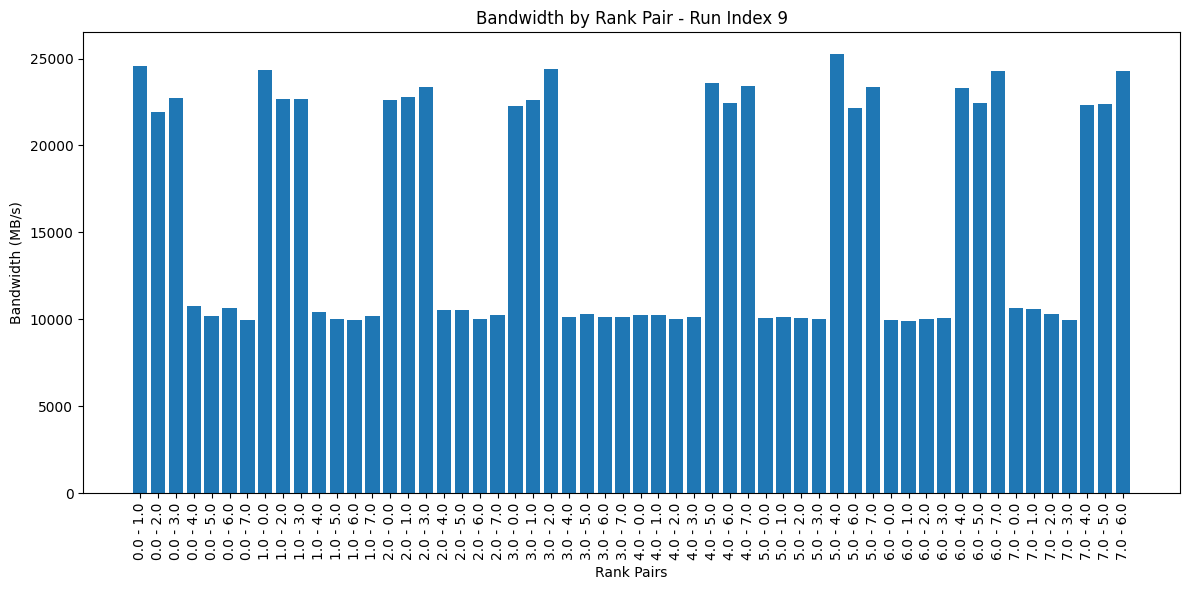

In [18]:
for run_index in bandwidths['Run Index'].unique():
    df_run = bandwidths[bandwidths['Run Index'] == run_index]
    
    plt.figure(figsize=(12, 6))
    x_labels = [f"{row['Rank A']} - {row['Rank B']}" for _, row in df_run.iterrows()]
    y_values = df_run['Bandwidth (MB/s)'].values
    
    plt.bar(range(len(x_labels)), y_values)
    plt.xticks(range(len(x_labels)), x_labels, rotation=90)
    plt.xlabel("Rank Pairs")
    plt.ylabel("Bandwidth (MB/s)")
    plt.title(f"Bandwidth by Rank Pair - Run Index {run_index}")
    plt.tight_layout()
    plt.show()

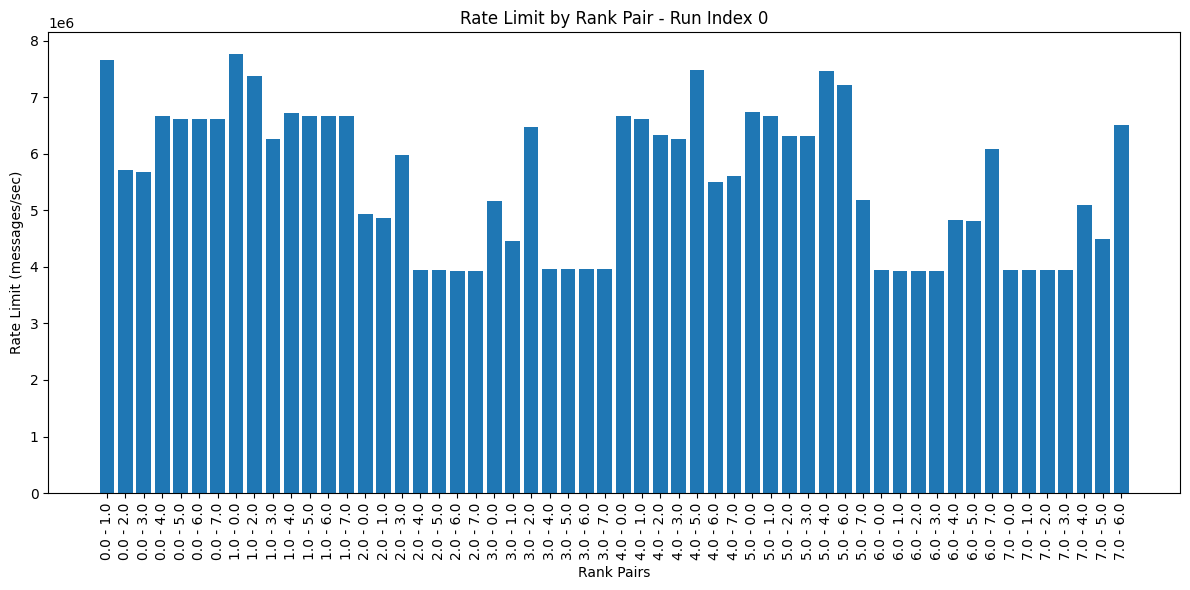

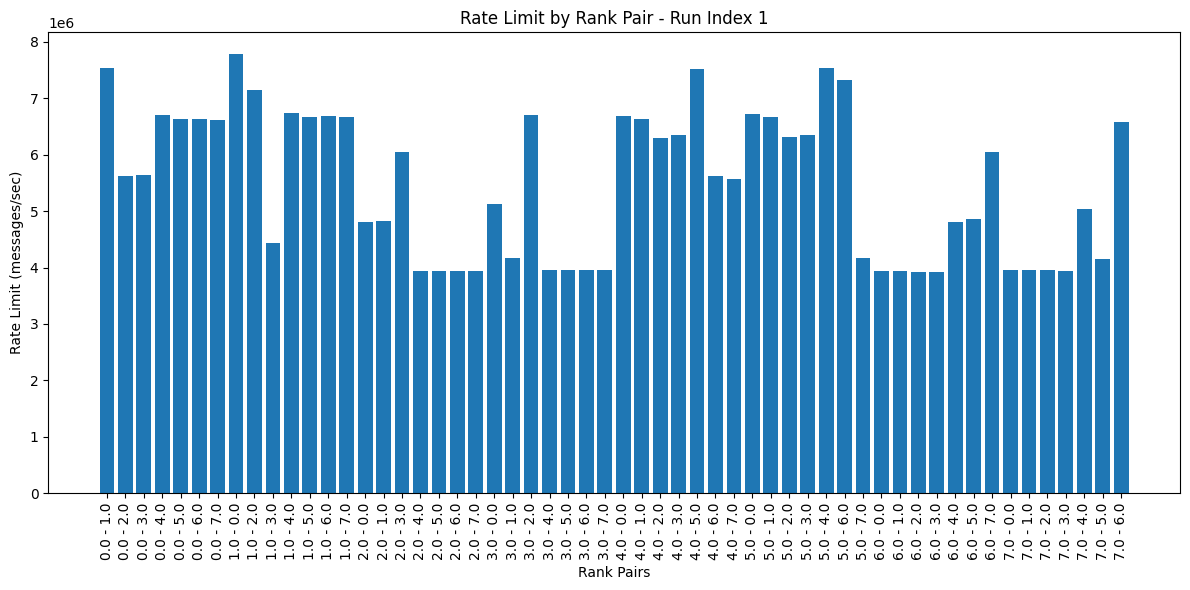

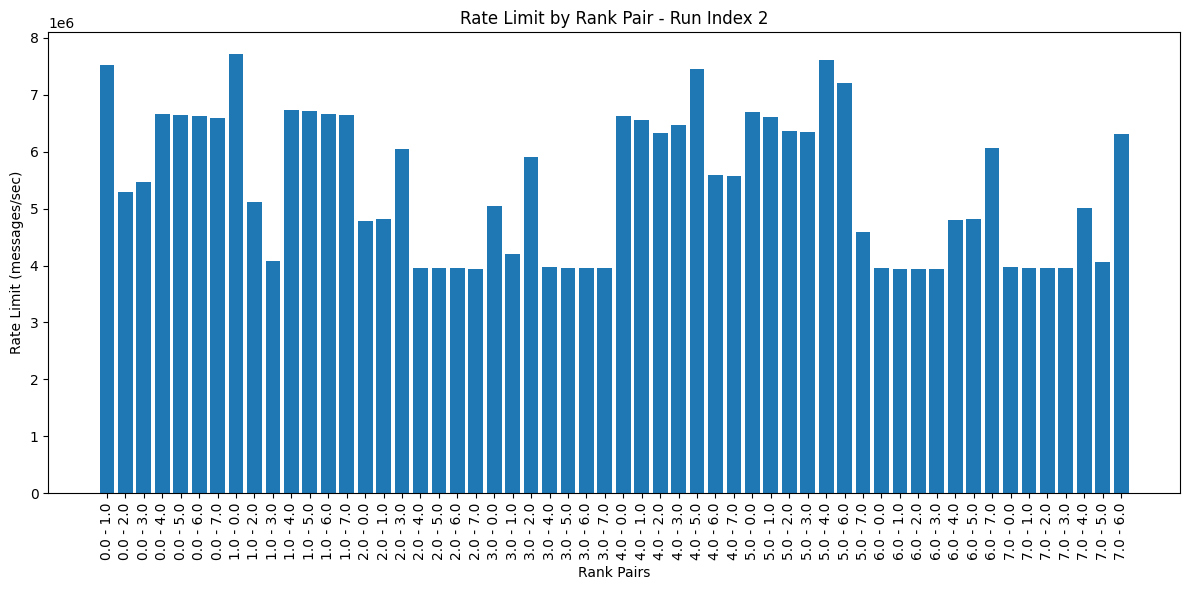

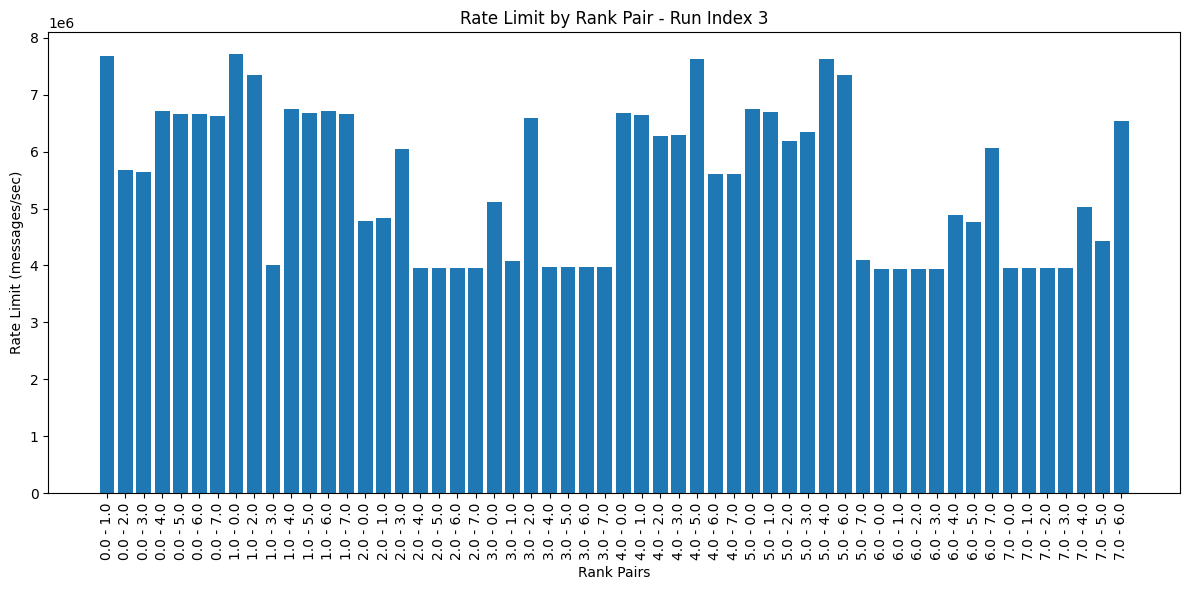

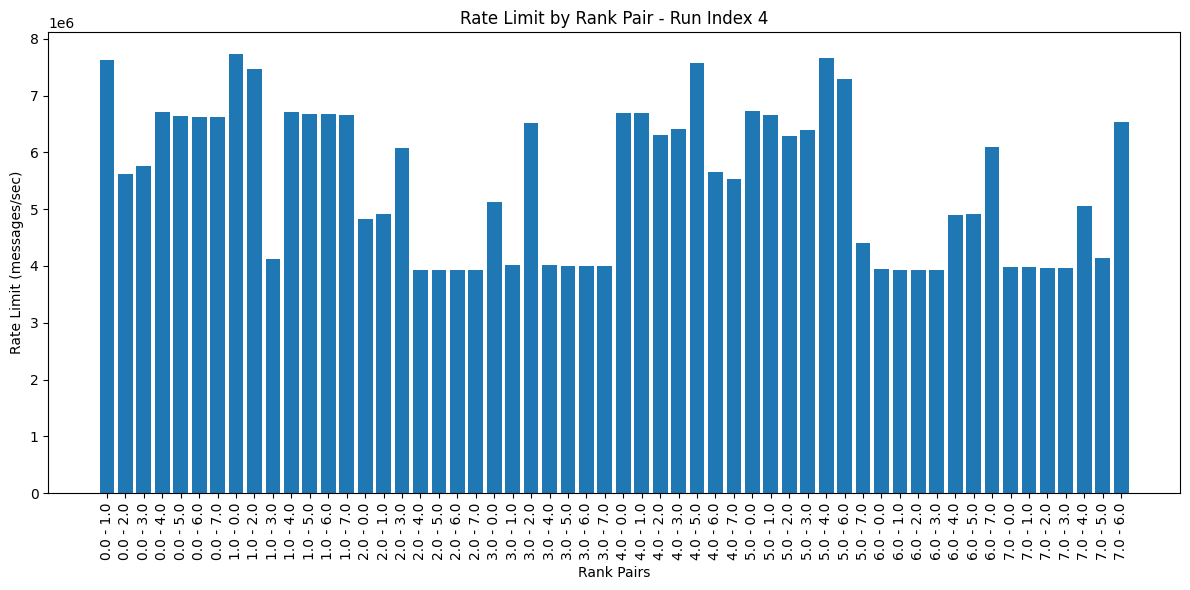

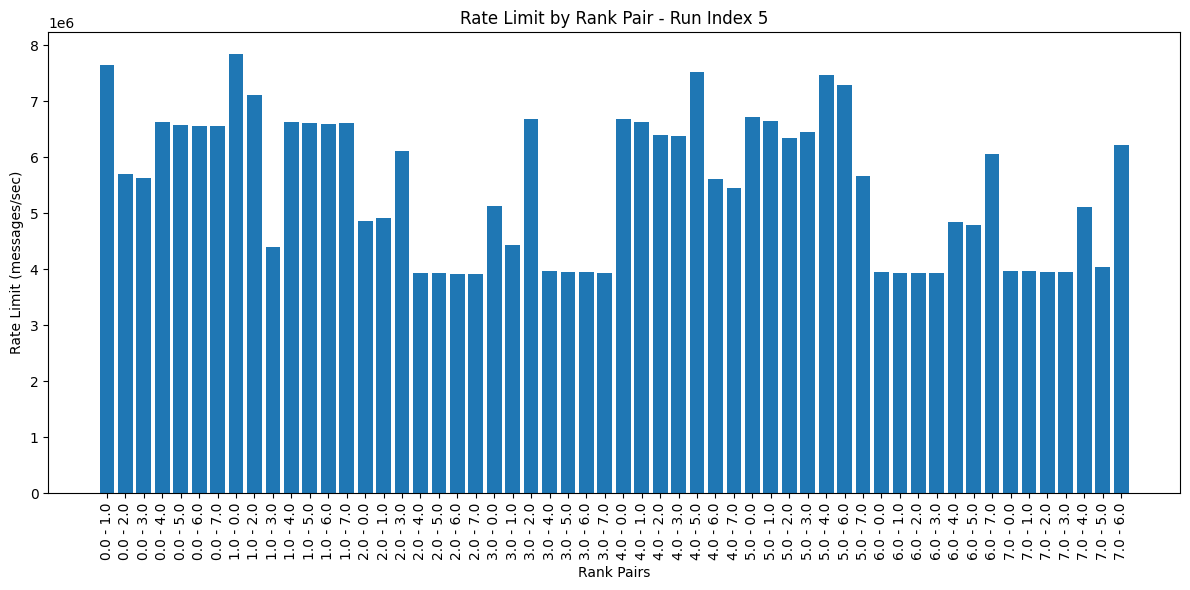

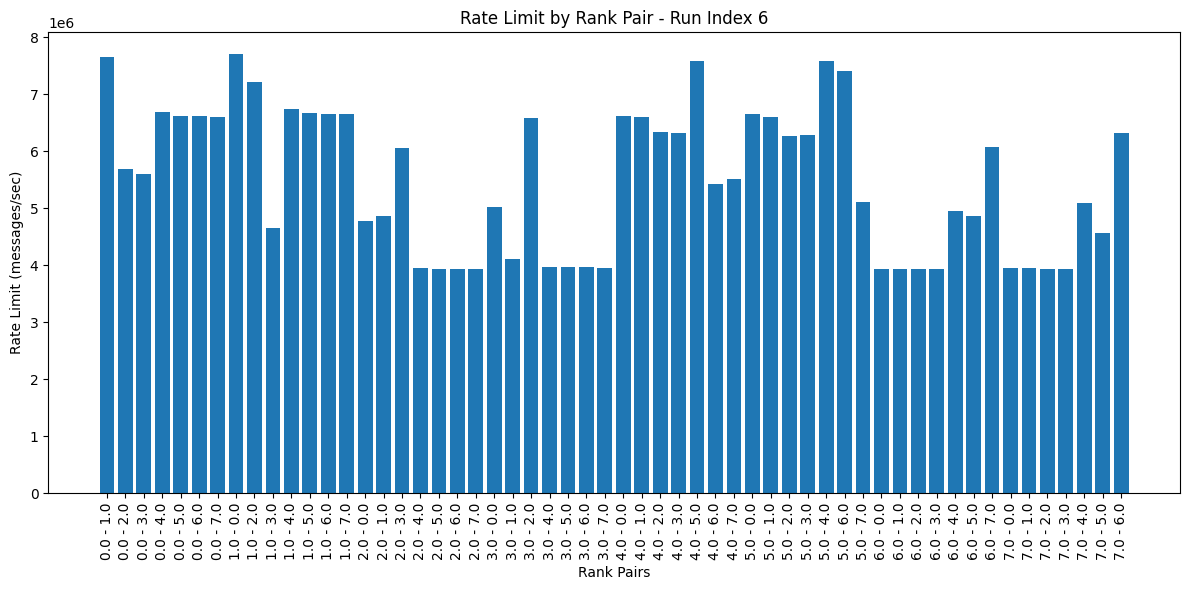

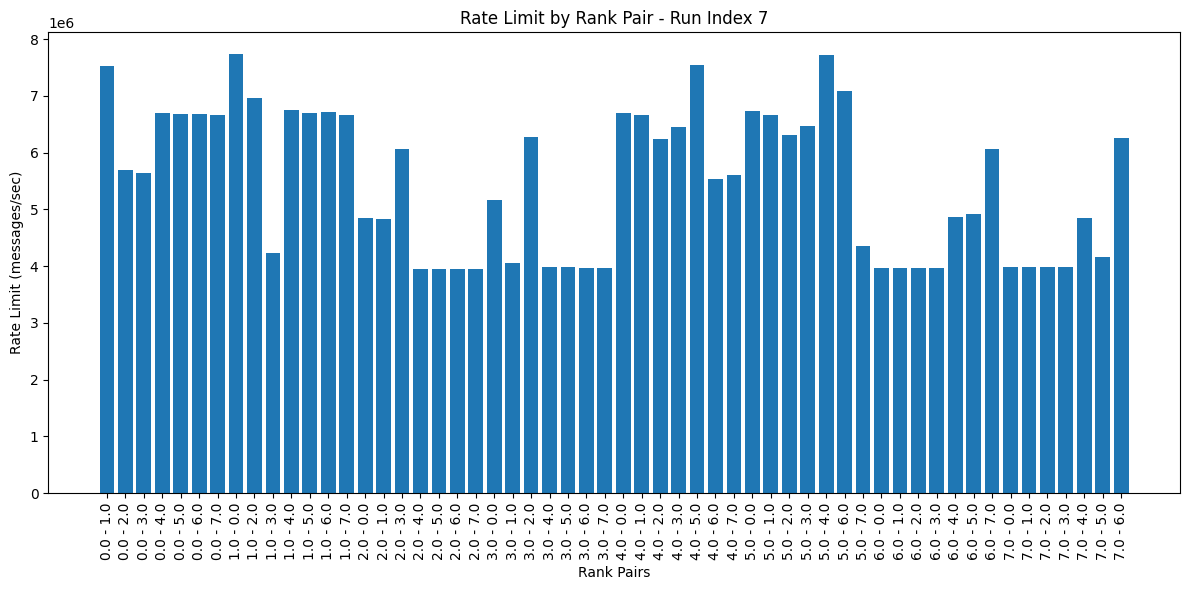

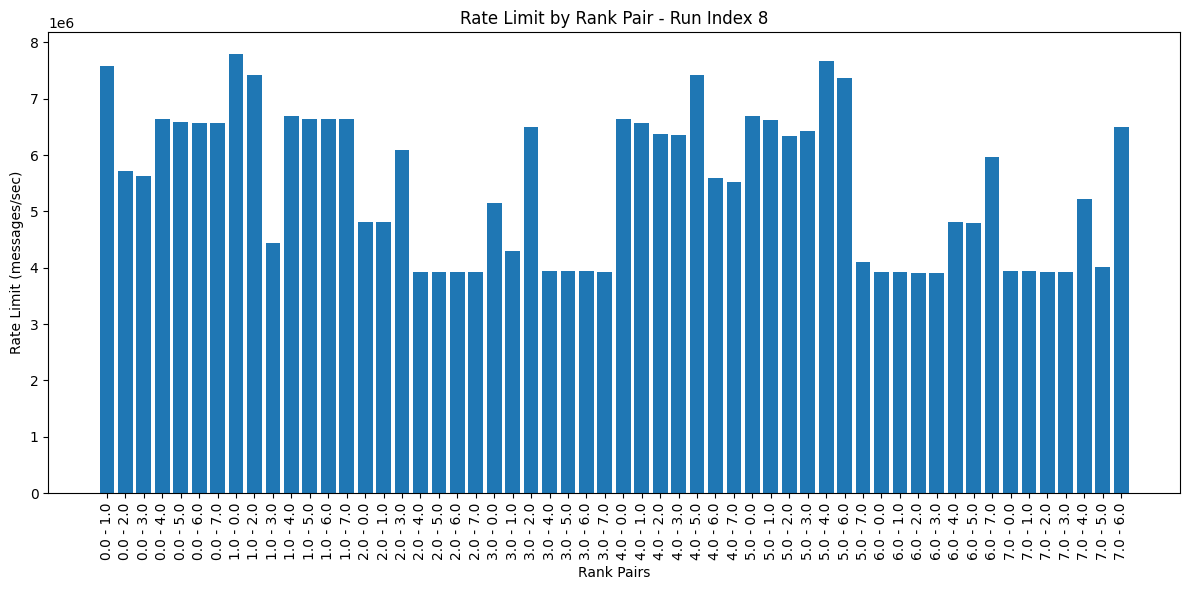

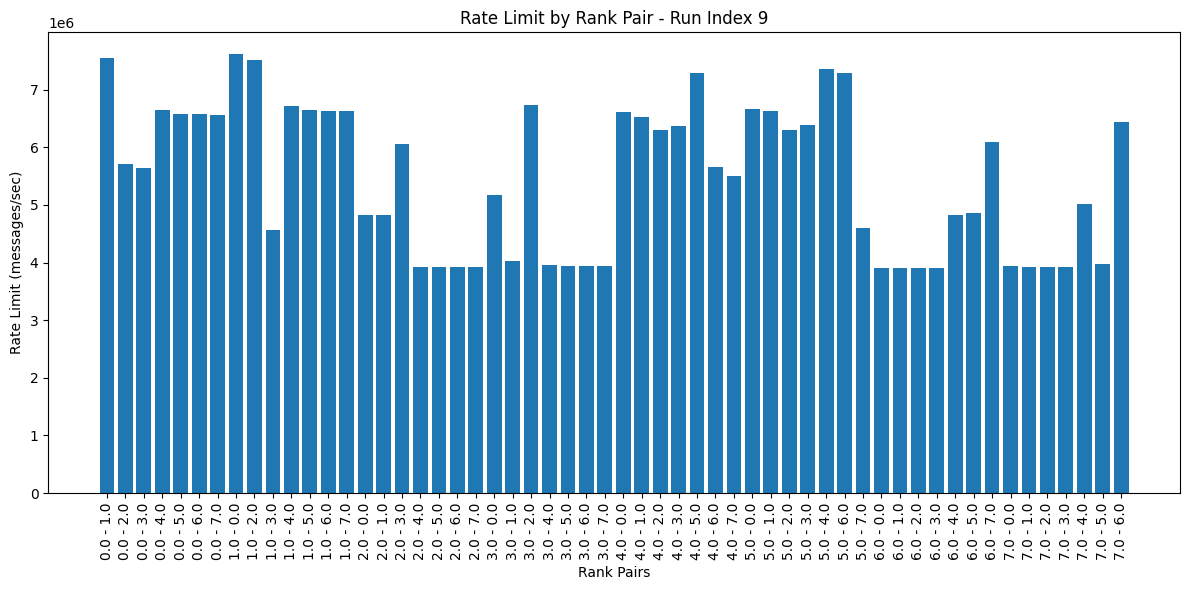

In [19]:
for run_index in rate_limits['Run Index'].unique():
    df_run = rate_limits[rate_limits['Run Index'] == run_index]
    
    plt.figure(figsize=(12, 6))
    x_labels = [f"{row['Rank A']} - {row['Rank B']}" for _, row in df_run.iterrows()]
    y_values = df_run['Rate Limit (messages/sec)'].values
    
    plt.bar(range(len(x_labels)), y_values)
    plt.xticks(range(len(x_labels)), x_labels, rotation=90)
    plt.xlabel("Rank Pairs")
    plt.ylabel("Rate Limit (messages/sec)")
    plt.title(f"Rate Limit by Rank Pair - Run Index {run_index}")
    plt.tight_layout()
    plt.show()

In [12]:
data_isolated_agg[(data_isolated_agg["App"] == "beatnik") & (data_isolated_agg["Num Nodes"] == 8)]

,App,Num Nodes,App Time Average Mean,App Time Average Median,App Time Average Std,MPI Time Average Mean,MPI Time Average Median,MPI Time Average Std,Total Messages Sent Mean,Total Messages Sent Median,Total Messages Sent Std,Total Bytes Sent Mean,Total Bytes Sent Median,Total Bytes Sent Std
2,beatnik,8,397.734375,396.977679,4.860808,99.906362,98.491295,3.282818,19996182.0,19996182.0,0.0,1.092655e+13,1.092655e+13,0.0


In [21]:
data_coscheduled_agg[(data_coscheduled_agg["App A"] == "beatnik") & (data_coscheduled_agg["App B"] == "beatnik") & (data_coscheduled_agg["Num Nodes"] == 8)]

,App A,App B,Num Nodes,App A Time Average Mean,App A Time Average Median,App A Time Average Std,App B Time Average Mean,App B Time Average Median,App B Time Average Std,App A MPI Time Average Mean,...,App A Total Messages Sent Std,App B Total Messages Sent Mean,App B Total Messages Sent Median,App B Total Messages Sent Std,App A Total Bytes Sent Mean,App A Total Bytes Sent Median,App A Total Bytes Sent Std,App B Total Bytes Sent Mean,App B Total Bytes Sent Median,App B Total Bytes Sent Std
6,beatnik,beatnik,8,449.054129,450.108259,18.916478,448.921875,449.018973,18.974308,158.350446,...,0.0,19996182.0,19996182.0,0.0,1.092655e+13,1.092655e+13,0.0,0.0,0.0,0.0


In [29]:
# App profiles
app_profiles = {}
for app in data_isolated_agg["App"].unique():
    filtered_data_isolated_agg = data_isolated_agg[(data_isolated_agg["App"] == app) & (data_isolated_agg["Num Nodes"] == 8)]
    app_profiles[app] = {}
    app_profiles[app]["App Time"] = filtered_data_isolated_agg["App Time Average Mean"].mean()
    app_profiles[app]["MPI Time"] = filtered_data_isolated_agg["MPI Time Average Mean"].mean()
    app_profiles[app]["Total Bytes"] = filtered_data_isolated_agg["Total Bytes Sent Mean"].mean()
    app_profiles[app]["Message Rate"] = filtered_data_isolated_agg["Total Messages Sent Mean"].mean()/filtered_data_isolated_agg["App Time Average Mean"].mean()
    app_profiles[app]["Message Size Avg"] = filtered_data_isolated_agg["Total Bytes Sent Mean"].mean()/filtered_data_isolated_agg["Total Messages Sent Mean"].mean()

In [37]:
# System profiles
C_bandwidth = bandwidths["Bandwidth (MB/s)"].median()
C_msg_rate = rate_limits["Rate Limit (messages/sec)"].median()
print(f"Bandwidth: {C_bandwidth} MB/s, Rate Limit: {C_msg_rate} messages/sec")

Bandwidth: 16720.864999999998 MB/s, Rate Limit: 5621335.0 messages/sec


In [40]:
# Beatnik - Beatnik co-scheduling test
lambda_sum = app_profiles["beatnik"]["Message Rate"] * 2
mu_sum = (app_profiles["beatnik"]["Message Size Avg"] * 2) / (app_profiles["beatnik"]["App Time"]*2)
s_bar = (app_profiles["beatnik"]["Message Rate"] * (app_profiles["beatnik"]["Message Size Avg"]/C_bandwidth) * 2) / lambda_sum
rho = lambda_sum * s_bar # utilization

R = s_bar / (1 - rho)
slowdown_a = R / (app_profiles["beatnik"]["Message Size Avg"]/C_bandwidth)
print(slowdown_a)

-3.0432592117230784e-07


In [41]:
print(rho)

3285951.7864064095
